In [1]:
import sys
sys.path.append('../')
import UTILS.utils as utils
import pandas as pd
from os import listdir
from os.path import splitext, join
from transformers import ViTImageProcessor, ViTModel
from PIL import Image

import torch
import polars as pl
import numpy as np

import cv2
import matplotlib.pyplot as plt

# EMBEDDING

In [2]:
image_processor = ViTImageProcessor.from_pretrained(
  'google/vit-base-patch16-224-in21k'
)
model = ViTModel.from_pretrained(
  'google/vit-base-patch16-224-in21k')

In [4]:
images = utils.get_files_in_directory("../../Data/STEREO_VIEWS/LEFT_IMAGE/")
images = images[1:]

In [5]:
from tqdm import tqdm

output = {}
for i, path in tqdm(enumerate(images)):
    image = Image.open(path)
    img = image.convert('RGB')
    w, h = img.size
    to_crop = h - w
    img = img.crop((0, to_crop,w, h))
    input = image_processor(img, return_tensors="pt")
    outputs = model(**input)
    pooler_output = outputs.pooler_output
    output[i] = pooler_output[0].detach().numpy() 
    output[i] = output[i] / np.linalg.norm(output[i], 2)

100it [01:12,  1.37it/s]


In [6]:
def get_distance_matrix(output):
    matrix = []
    for ref in range(0, 100):
        similarity = []
        for image in range(0, 100):
            similarity += [1 - (np.dot(output[ref], output[image]))]
        matrix.append(similarity)
    return matrix

distance_matrix = get_distance_matrix(output)

In [7]:
def create_clusters(labels):
    final_dict = {}
    for i, label in enumerate(labels):
        if label in final_dict.keys():
            final_dict[label] += [i]
        else:
            final_dict[label] = [i]
    return final_dict

In [8]:
def display_images(image_indexes):
    for idx in image_indexes:
        img = cv2.imread(images[idx])
        plt.figure()
        plt.imshow(img)
    plt.show()

In [9]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=10, linkage='complete', metric="precomputed").fit(distance_matrix)

label_dict = create_clusters(model.labels_)

In [26]:
distr = [len(x) for x in label_dict.values()]
data = pd.DataFrame(zip(label_dict.keys(), distr), columns=["Cats", "Num"])

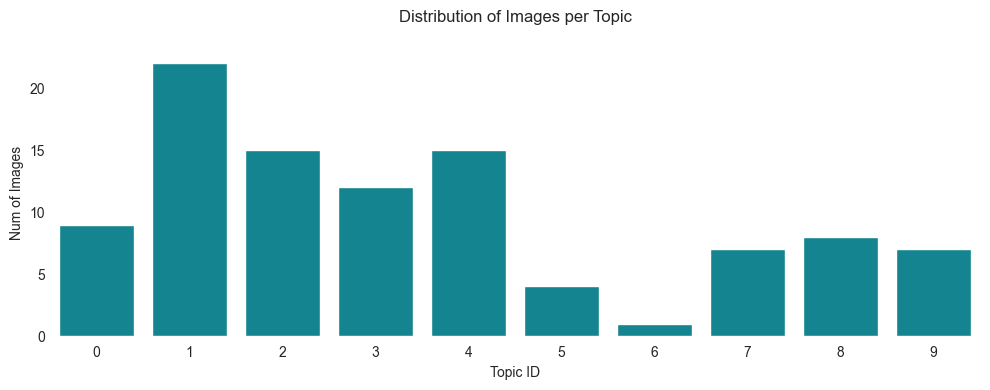

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

sns.set_style("white") 
plt.figure(figsize=(10, 4)) 

ax = sns.barplot(x='Cats', y='Num', data=data,
                 color='#0094a6') 

plt.xlabel('Topic ID') 
sns.despine(left=True, bottom=True, top=True, right=True)
ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
plt.ylabel('Num of Images')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
plt.title('Distribution of Images per Topic', pad=20)

plt.tight_layout()
plt.show()